In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [73]:
df = pd.read_csv('drug200.csv')
df.columns = df.columns.str.strip()
print(f"Veri seti boyutu: {df.shape}")
print(f"Sınıf dağılımı:\n{df['Drug'].value_counts()}")

Veri seti boyutu: (200, 6)
Sınıf dağılımı:
Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


In [74]:
df['Sex'] = df['Sex'].map({'F': 0, 'M': 1})
df['BP'] = df['BP'].map({'LOW': 0, 'NORMAL': 1, 'HIGH': 2})
df['Cholesterol'] = df['Cholesterol'].map({'NORMAL': 0, 'HIGH': 1})

df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,2,1,25.355,drugY
1,47,1,0,1,13.093,drugC
2,47,1,0,1,10.114,drugC
3,28,0,1,1,7.798,drugX
4,61,0,0,1,18.043,drugY


In [75]:
X = df.drop('Drug', axis=1)
y = df['Drug']

print(f"Özellik matrisi boyutu: {X.shape}")
print(f"Hedef vektörü boyutu: {y.shape}")

Özellik matrisi boyutu: (200, 5)
Hedef vektörü boyutu: (200,)


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape}")
print(f"Test seti: {X_test.shape}")

Eğitim seti: (140, 5)
Test seti: (60, 5)


In [82]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [79]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Modelin Doğruluk Oranı (Accuracy): {accuracy:.4f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))

Modelin Doğruluk Oranı (Accuracy): 0.9833

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      0.80      0.89         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      1.00      1.00        16
       drugY       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



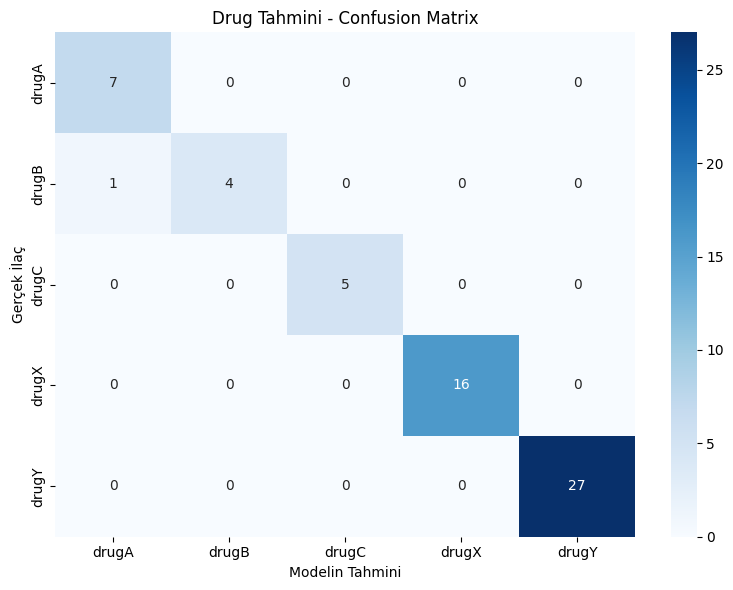

In [80]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Drug Tahmini - Confusion Matrix')
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek İlaç')
plt.tight_layout()
plt.show()

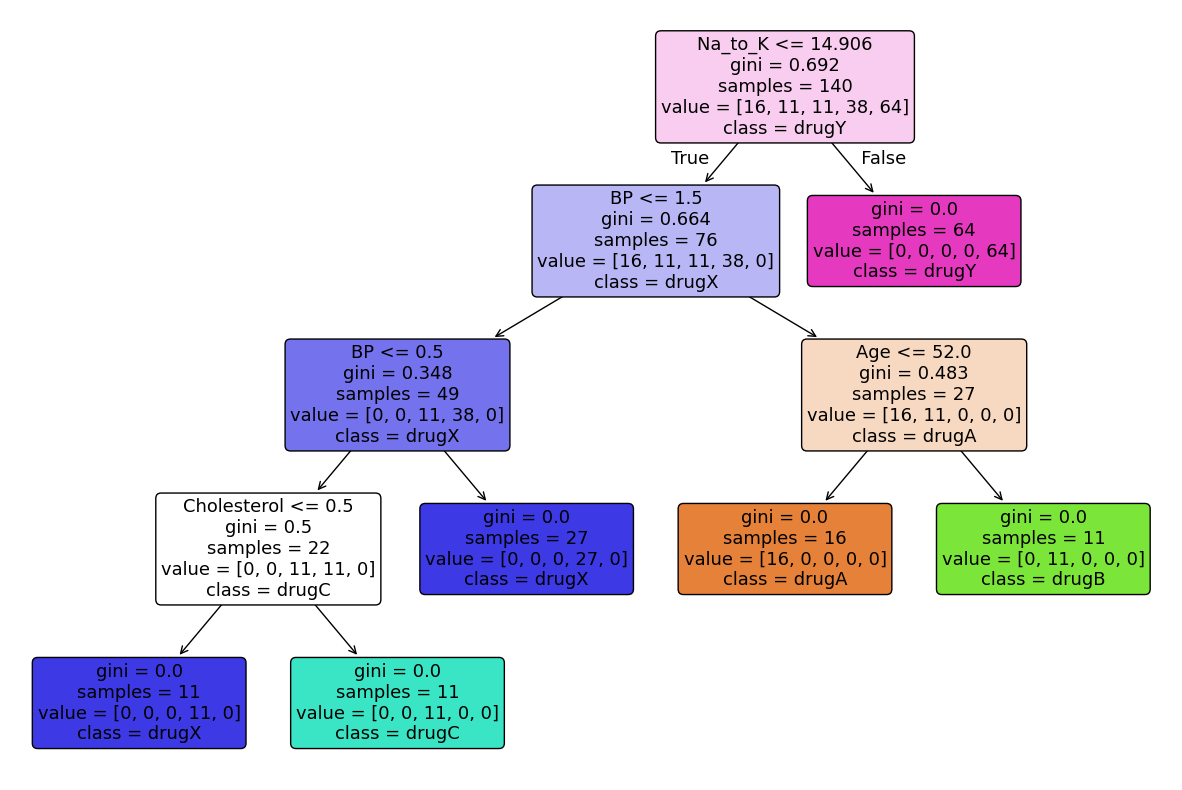

In [81]:
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True, rounded=True)
plt.show()